In [2]:
# --- CELL 1: LIBRARIES & SETUP ---
!pip install optuna optuna-integration -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import optuna
import time

# Optuna Integration
from optuna.integration import TFKerasPruningCallback
from optuna.pruners import MedianPruner

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# Deep Learning Libraries
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

sns.set_style("whitegrid")
print("Libraries Imported Successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 5.1 MB/s eta 0:00:00
Libraries Imported Successfully


In [4]:
# --- CELL 2: DATA LOADING & PREPROCESSING ---
print("🔄 Veri Yükleniyor...")
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")

# Leakage Temizliği
leakage_cols = ['Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
                'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
                'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
                'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

target = "Simple_Building_Energy_Rating"
X = df.drop(columns=[target])
y = df[target].copy()

# Feature Engineering
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] +
                       X["Wall_Insulation_U-Value"] * (1 - X["Window_to_Wall_Ratio"]))
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] +
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

# Preprocessing Pipeline
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# Split (Train/Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Transform
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
y_train_oh = to_categorical(y_train, n_classes)
y_test_oh = to_categorical(y_test, n_classes)

print(f"✅ Veri Hazır. Eğitim Seti: {X_train.shape}")

🔄 Veri Yükleniyor...
✅ Veri Hazır. Eğitim Seti: (838849, 31)


In [5]:
# --- CELL 3: MODEL ARCHITECTURE & LOSS FUNCTION ---

# Focal Loss
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# ResNet Model Builder
def build_resnet_model(params):
    input_layer = Input(shape=(X_train.shape[1],))

    # Giriş Katmanı
    x = Dense(int(params['units']), kernel_regularizer=l2(0.0001))(input_layer)
    x = BatchNormalization()(x)
    x = Activation(params['activation'])(x)
    x = Dropout(params['dropout'])(x)

    # Residual Bloklar
    for _ in range(int(params['n_layers'])):
        shortcut = x
        x = Dense(int(params['units']), kernel_regularizer=l2(0.0001))(x)
        x = BatchNormalization()(x)
        x = Activation(params['activation'])(x)
        x = Dropout(params['dropout'])(x)
        x = Add()([x, shortcut])
        x = Activation(params['activation'])(x)

    output_layer = Dense(n_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output_layer)

    if params['optimizer'] == 'adam': opt = Adam(learning_rate=params['learning_rate'])
    elif params['optimizer'] == 'rmsprop': opt = RMSprop(learning_rate=params['learning_rate'])
    else: opt = SGD(learning_rate=params['learning_rate'])

    model.compile(loss=categorical_focal_loss(), optimizer=opt, metrics=['accuracy'])
    return model

print("Model Functions Defined")

Model Functions Defined


In [6]:
# --- CELL 4: OPTUNA OPTIMIZATION ---
print("\n🔍 Optuna Başlıyor (Pruning + Full Data)...")

# RUNTIME BAŞLANGIÇ
optuna_start_time = time.time()

def objective_optuna(trial):
    params = {
        'learning_rate': trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical("batch_size", [256, 512, 1024]),
        'n_layers': trial.suggest_int("n_layers", 2, 4),
        'units': trial.suggest_int("units", 64, 1024, step=64),
        'activation': trial.suggest_categorical("activation", ["relu", "swish"]),
        'optimizer': trial.suggest_categorical("optimizer", ["adam", "rmsprop"]),
        'dropout': trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    }

    model = build_resnet_model(params)

    callbacks = [
        TFKerasPruningCallback(trial, monitor='val_accuracy'),
        EarlyStopping(monitor='val_loss', patience=4, verbose=0)
    ]

    history = model.fit(
        X_train, y_train_oh,
        validation_split=0.2,
        epochs=12,
        batch_size=params['batch_size'],
        callbacks=callbacks,
        verbose=0
    )

    return max(history.history['val_accuracy'])

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1, interval_steps=1)
)

# 25 Deneme
study.optimize(objective_optuna, n_trials=25)

# RUNTIME BİTİŞ & HESAPLAMA
optuna_end_time = time.time()
optuna_duration = optuna_end_time - optuna_start_time

print(f"Optuna En İyi Parametreler: {study.best_params}")
print(f"Optuna Toplam Çalışma Süresi: {optuna_duration/60:.2f} dakika")

[I 2025-12-26 23:59:55,143] A new study created in memory with name: no-name-5dbb7498-e544-4dce-be6b-76882a819b0f



🔍 Optuna Başlıyor (Pruning + Full Data)...


[I 2025-12-27 00:01:19,181] Trial 0 finished with value: 0.8392561078071594 and parameters: {'learning_rate': 0.0001988129657725353, 'batch_size': 512, 'n_layers': 2, 'units': 640, 'activation': 'relu', 'optimizer': 'adam', 'dropout': 0.1}. Best is trial 0 with value: 0.8392561078071594.
[I 2025-12-27 00:03:45,654] Trial 1 finished with value: 0.8302735686302185 and parameters: {'learning_rate': 0.0004669825176435291, 'batch_size': 256, 'n_layers': 4, 'units': 256, 'activation': 'relu', 'optimizer': 'rmsprop', 'dropout': 0.1}. Best is trial 0 with value: 0.8392561078071594.
[I 2025-12-27 00:04:16,541] Trial 2 finished with value: 0.7292841672897339 and parameters: {'learning_rate': 0.008048997430701196, 'batch_size': 1024, 'n_layers': 4, 'units': 256, 'activation': 'swish', 'optimizer': 'adam', 'dropout': 0.5}. Best is trial 0 with value: 0.8392561078071594.
[I 2025-12-27 00:05:12,043] Trial 3 finished with value: 0.8299159407615662 and parameters: {'learning_rate': 0.00100969706091701

Optuna En İyi Parametreler: {'learning_rate': 0.0002053081101089717, 'batch_size': 256, 'n_layers': 4, 'units': 512, 'activation': 'relu', 'optimizer': 'adam', 'dropout': 0.1}
Optuna Toplam Çalışma Süresi: 22.98 dakika


In [7]:
# --- CELL 5: FINAL MODEL TRAINING ---
print("\n KAZANAN PARAMETRELERLE FİNAL EĞİTİM BAŞLIYOR...")

# RUNTIME BAŞLANGIÇ
train_start_time = time.time()

best_params = study.best_params
final_model = build_resnet_model(best_params)

checkpoint_path = "final_optimized_resnet.keras"
callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max')
]

history_final = final_model.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=100,
    batch_size=best_params['batch_size'],
    callbacks=callbacks_final,
    verbose=1
)

# RUNTIME BİTİŞ & HESAPLAMA
train_end_time = time.time()
train_duration = train_end_time - train_start_time

print(f" Eğitim Tamamlandı.")
print(f" Final Eğitim Süresi: {train_duration/60:.2f} dakika")


 KAZANAN PARAMETRELERLE FİNAL EĞİTİM BAŞLIYOR...
Epoch 1/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.6796 - loss: 0.3056 - val_accuracy: 0.7543 - val_loss: 0.1394 - learning_rate: 2.0531e-04
Epoch 2/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7610 - loss: 0.1177 - val_accuracy: 0.7981 - val_loss: 0.0648 - learning_rate: 2.0531e-04
Epoch 3/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7822 - loss: 0.0647 - val_accuracy: 0.7974 - val_loss: 0.0516 - learning_rate: 2.0531e-04
Epoch 4/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7936 - loss: 0.0527 - val_accuracy: 0.8192 - val_loss: 0.0440 - learning_rate: 2.0531e-04
Epoch 5/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8014 - loss: 0.0481 - val_accuracy: 0.8003 - val_loss: 0.0441 - learning_rate: 2.0531e-04
Epoch 6/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8042 - loss: 0.0461 - val_accuracy: 0.8288 - val_loss: 0.0395 - learning_rate: 2

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step

=== 1. CLASS-WISE PERFORMANCE TABLE ===
              precision    recall  f1-score        support
A              0.965187  0.967083  0.966134   43777.000000
B              0.926772  0.914132  0.920409   54258.000000
C              0.905367  0.900860  0.903108   54852.000000
D              0.843587  0.842853  0.843220   26453.000000
E              0.793983  0.836742  0.814802   14131.000000
F              0.762918  0.716604  0.739036    6655.000000
G              0.897937  0.953479  0.924875    9587.000000
accuracy       0.903039  0.903039  0.903039       0.903039
macro avg      0.870822  0.875965  0.873083  209713.000000
weighted avg   0.903234  0.903039  0.903025  209713.000000


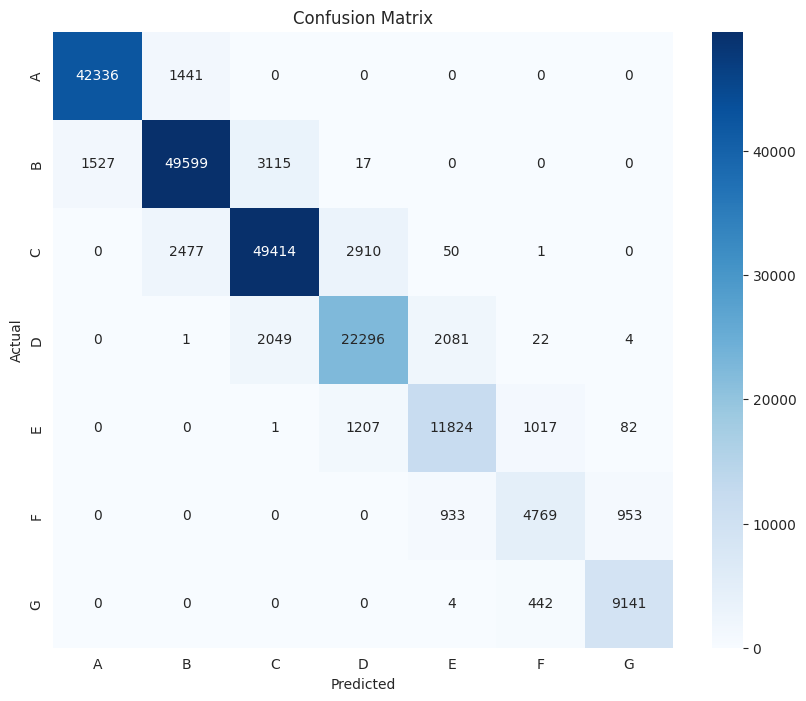

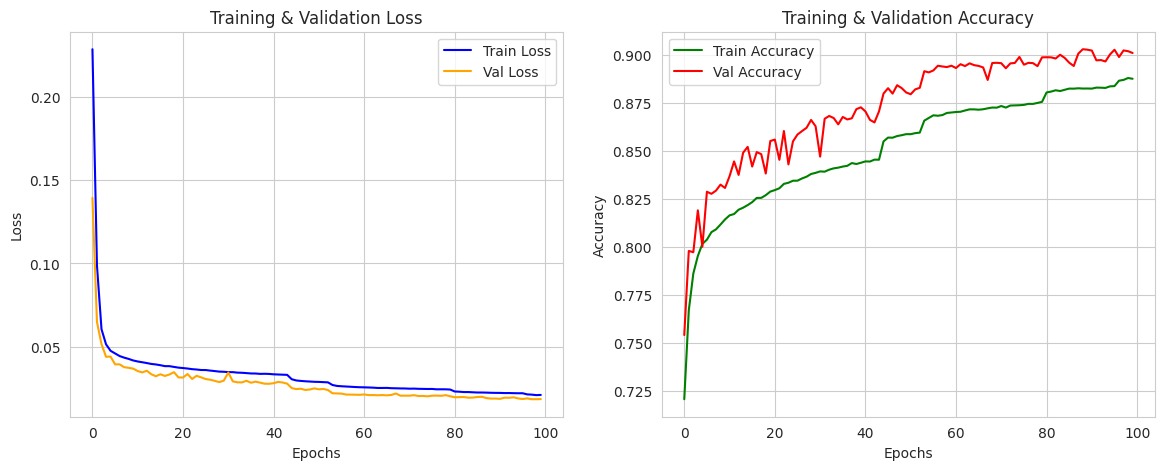


=== 4. VALIDATION & TEST COMMENTS ===
• Best Validation Accuracy: 90.30%
• Final Test Accuracy: 90.30%

=== 5. COHEN'S KAPPA SCORE: 0.8786 ===


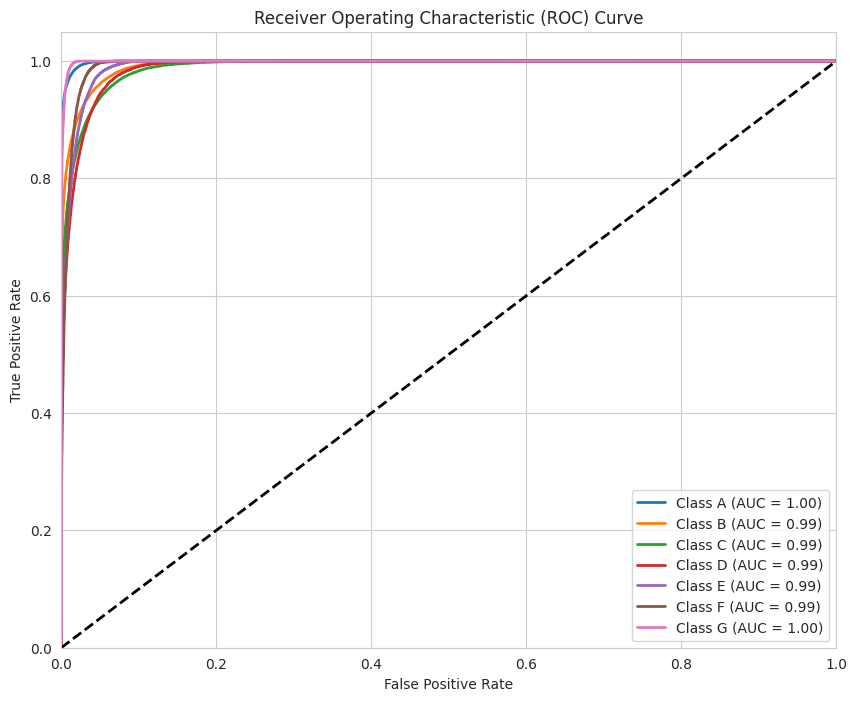

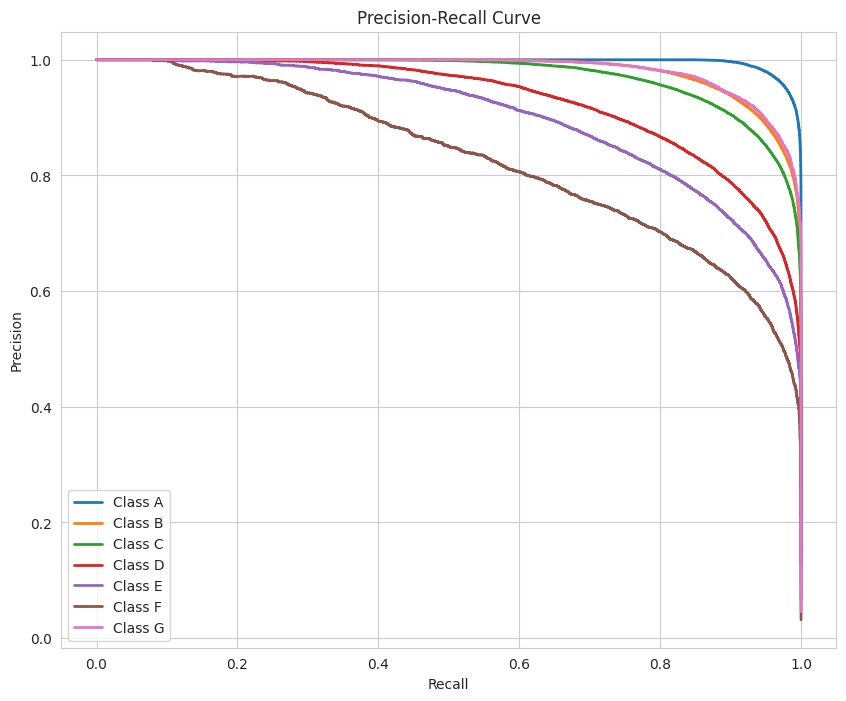

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle

final_model = load_model(checkpoint_path, custom_objects={'focal_loss_fixed': categorical_focal_loss()})
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ========================================================
#  Accuracy, Precision, Recall, F1
# ========================================================
print("\n=== 1. CLASS-WISE PERFORMANCE TABLE ===")
report_dict = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
# Sadece sınıfları ve genel ortalamaları gösterelim
print(df_report)

# ========================================================
#  Confusion Matrix
# ========================================================
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ========================================================
#  Training/Validation Loss & Accuracy Graphs
# ========================================================
plt.figure(figsize=(14, 5))
# Loss Grafiği
plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'], label='Train Loss', color='blue')
plt.plot(history_final.history['val_loss'], label='Val Loss', color='orange')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Grafiği
plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history_final.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ========================================================
#  Validation & Test Yorumları
# ========================================================
print("\n=== 4. VALIDATION & TEST COMMENTS ===")
val_acc = max(history_final.history['val_accuracy'])
test_acc = np.mean(y_pred == y_test)
print(f"• Best Validation Accuracy: {val_acc*100:.2f}%")
print(f"• Final Test Accuracy: {test_acc*100:.2f}%")

# ========================================================
#  Cohen's Kappa Score
# ========================================================
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\n=== 5. COHEN'S KAPPA SCORE: {kappa:.4f} ===")

# ========================================================
#  AUC-ROC Curve
# ========================================================
y_test_bin = label_binarize(y_test, classes=range(n_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# ========================================================
#  Precision-Recall Curve
# ========================================================
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {classes[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="best")
plt.show()